In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme()

In [8]:
LOAD_PATH = Path("../data/data.parquet")
data = pd.read_parquet(LOAD_PATH)
print(data.shape)

data.head()

(9089, 32)


,index,value,coordinates,period.label,period.interval,period.datetime_from.utc,period.datetime_from.local,period.datetime_to.utc,period.datetime_to.local,parameter.id,...,coverage.expected_count,coverage.expected_interval,coverage.observed_count,coverage.observed_interval,coverage.percent_complete,coverage.percent_coverage,coverage.datetime_from.utc,coverage.datetime_from.local,coverage.datetime_to.utc,coverage.datetime_to.local
0,0,64.5,None,1hour,01:00:00,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00
1,1,476.0,None,1hour,01:00:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00
2,2,475.0,None,1hour,01:00:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00
3,3,361.0,None,1hour,01:00:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00
4,4,310.0,None,1hour,01:00:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00


In [9]:
data.columns

Index(['index', 'value', 'coordinates', 'period.label', 'period.interval',
       'period.datetime_from.utc', 'period.datetime_from.local',
       'period.datetime_to.utc', 'period.datetime_to.local', 'parameter.id',
       'parameter.name', 'parameter.units', 'parameter.display_name',
       'summary.min', 'summary.q02', 'summary.q25', 'summary.median',
       'summary.q75', 'summary.q98', 'summary.max', 'summary.sd',
       'summary.avg', 'coverage.expected_count', 'coverage.expected_interval',
       'coverage.observed_count', 'coverage.observed_interval',
       'coverage.percent_complete', 'coverage.percent_coverage',
       'coverage.datetime_from.utc', 'coverage.datetime_from.local',
       'coverage.datetime_to.utc', 'coverage.datetime_to.local'],
      dtype='object')

In [16]:
df = data.loc[:, [
    "value",
    "period.datetime_from.local",
    "parameter.name"
]]

In [18]:
df = df.rename(columns={
    "period.datetime_from.local": "timestamp",
    "parameter.name": "parameter"
})

In [19]:
df.head()

,value,timestamp,parameter
0,64.5,2025-01-01T00:00:00+01:00,pm25
1,476.0,2025-01-01T01:00:00+01:00,pm25
2,475.0,2025-01-01T02:00:00+01:00,pm25
3,361.0,2025-01-01T03:00:00+01:00,pm25
4,310.0,2025-01-01T04:00:00+01:00,pm25


In [20]:
df2 = df.pivot(
    columns="parameter",
    index="timestamp",
    values="value"
    ).reset_index().copy()

In [22]:
df2["timestamp"] = pd.to_datetime(df2["timestamp"], utc=True)

In [24]:
df2

parameter,timestamp,pm25
0,2024-12-31 23:00:00+00:00,64.5
1,2025-01-01 00:00:00+00:00,476.0
2,2025-01-01 01:00:00+00:00,475.0
3,2025-01-01 02:00:00+00:00,361.0
4,2025-01-01 03:00:00+00:00,310.0
...,...,...
9084,2026-02-28 18:00:00+00:00,29.0
9085,2026-02-28 19:00:00+00:00,19.1
9086,2026-02-28 20:00:00+00:00,22.1
9087,2026-02-28 21:00:00+00:00,23.3


# Correlations

<Axes: xlabel='parameter', ylabel='parameter'>

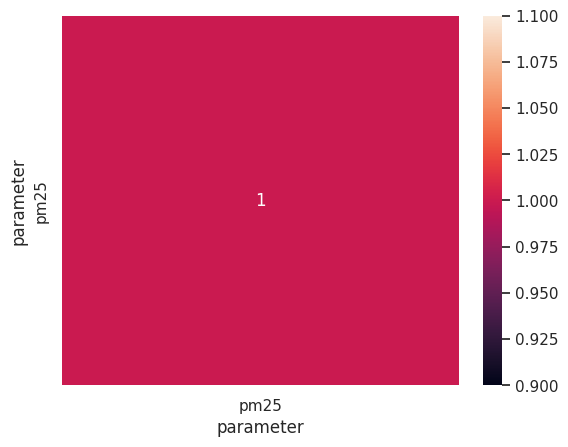

In [23]:
sns.heatmap(
    df2.drop("timestamp", axis=1).corr(),
    annot=True,
    )

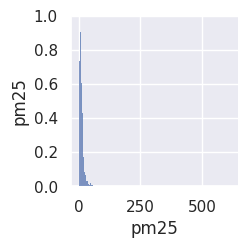

In [25]:
sns.pairplot(df2)

# Over time

In [29]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0
        
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2['year'] = df2['timestamp'].dt.year
df2['month'] = df2['timestamp'].dt.month
df2['day_of_week'] = df2['timestamp'].dt.day_of_week
df2['hour_of_day'] = df2['timestamp'].dt.hour
df2['is_weekend'] = df2['day_of_week'].apply(lambda day: is_weekend(day))

<Axes: title={'center': 'mean pm25 by week'}, xlabel='day_of_week'>

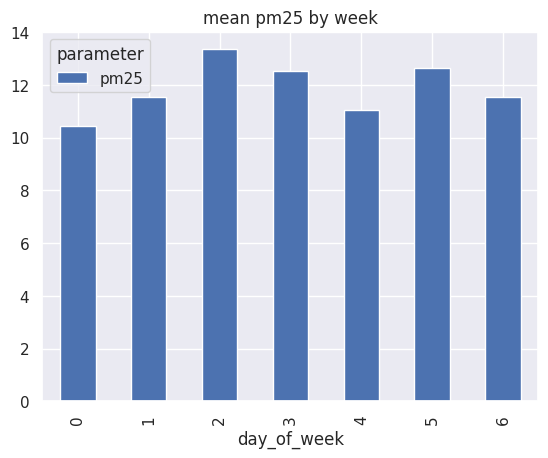

In [30]:
df2 \
    .groupby("day_of_week") \
    .agg({"pm25":"mean"}) \
    .plot.bar(title="mean pm25 by week")

<Axes: title={'center': 'pm25 concentration over day'}, xlabel='hour_of_day'>

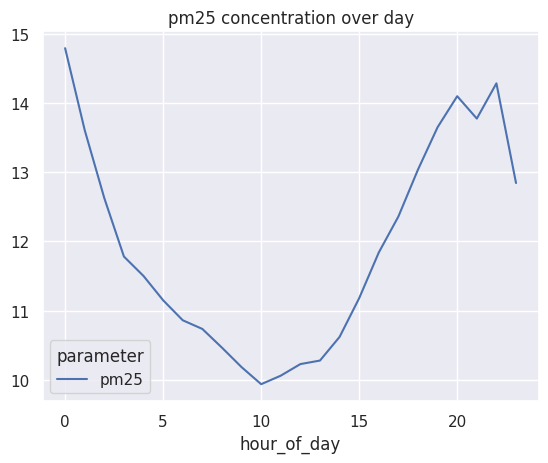

In [31]:
df2 \
.groupby("hour_of_day") \
.agg({"pm25": "mean"}) \
.plot.line(title="pm25 concentration over day")

<Axes: xlabel='timestamp', ylabel='pm25'>

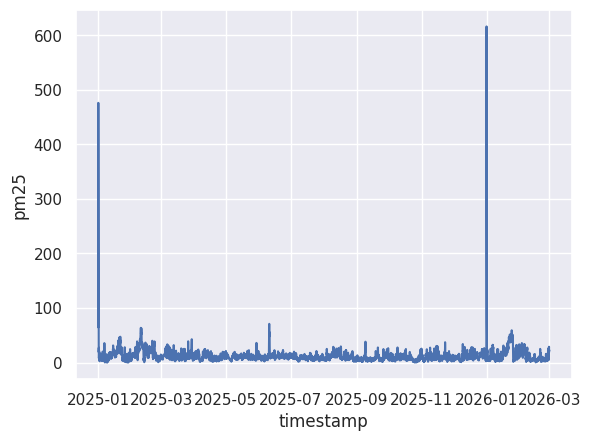

In [ ]:
sns.lineplot(data=df2, x="timestamp", y="pm25")